# 📊Demand Sensing & Forecasting using Ensemble Machine Learning

## 🎯Objective
Forecast future product demand using machine learning ensemble models with OOT validation and stacking.

In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [14]:


Data_Results = pd.read_csv(
    r"C:\Users\Lenovo\Downloads\DataPreparationDemandSensing(in).csv"
)

Data_Results['SalesMonth'] = pd.to_datetime(
    dict(
        year=Data_Results['Year'],
        month=Data_Results['Month'],
        day=1
    )
)

Data_Results['SalesMonth'] = (
    Data_Results['SalesMonth']
    .dt.to_period('M')
    .dt.to_timestamp()
)

Data_Results = Data_Results.sort_values(
    'SalesMonth'
)

if 'SoldToParty' in Data_Results.columns:

    Data_Results.rename(
        columns={
            'SoldToParty': 'Material_Region'
        },
        inplace=True
    )

latest_month = Data_Results['SalesMonth'].max()

# last 5 months horizon
date = latest_month - pd.DateOffset(months=5)


oot_months = sorted(
    Data_Results[
        Data_Results['SalesMonth'] >= date
    ]['SalesMonth'].unique()
)

print("Latest Month:")
print(latest_month)

print("\nOOT Start Date:")
print(date)

print("\nOOT Months:")
print(oot_months)

print("\nTotal OOT Months:")
print(len(oot_months))

Latest Month:
2026-03-01 00:00:00

OOT Start Date:
2025-10-01 00:00:00

OOT Months:
[Timestamp('2025-10-01 00:00:00'), Timestamp('2025-11-01 00:00:00'), Timestamp('2025-12-01 00:00:00'), Timestamp('2026-01-01 00:00:00'), Timestamp('2026-02-01 00:00:00'), Timestamp('2026-03-01 00:00:00')]

Total OOT Months:
6


In [15]:
Data_Results

,BilledQuantity_lead1,Period,Material_Region,Month,Year,Region,Category,BilledQuantity_lag0,BilledQuantity_lag1,BilledQuantity_lag2,...,roll_std_3,momentum,cv_3,stock_cover,zero_flag,zero_rate_6,trend_idx,is_period_1,is_period_2,SalesMonth
0,138,1,AHM_F2W0-48S-14L-A2,1,2024,AHM,WALKER,232,NaN,NaN,...,NaN,NaN,NaN,NaN,0,NaN,0,1,0,2024-01-01
99657,0,1,JAL_F4W5-HXDIN52RMFEFB,1,2024,JAL,STRANGER,0,NaN,NaN,...,NaN,NaN,NaN,NaN,1,NaN,0,1,0,2024-01-01
175068,6,1,VIJ_HX00-GQP12V1450N,1,2024,VIJ,STRANGER,5,NaN,NaN,...,NaN,NaN,NaN,NaN,0,NaN,0,1,0,2024-01-01
13068,128,1,BAN_FXL0-XLTX14,1,2024,BAN,WALKER,40,NaN,NaN,...,NaN,NaN,NaN,NaN,0,NaN,0,1,0,2024-01-01
154197,3,1,PUN_HX00-GQP12V1450N,1,2024,PUN,STRANGER,6,NaN,NaN,...,NaN,NaN,NaN,NaN,0,NaN,0,1,0,2024-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112967,0,1,KOC_F4W5-36S-700RF,3,2026,KOC,STRANGER,8,1.0,7.0,...,3.785939,0.375000,1.419727,0.000000,0,0.333333,52,1,0,2026-03-01
112994,45,1,KOC_F4W5-48S-105D31L,3,2026,KOC,RUNNER,107,62.0,53.0,...,4.582576,1.068966,0.079010,0.189655,0,0.000000,52,1,0,2026-03-01
113021,11,1,KOC_F4W5-48S-105D31R,3,2026,KOC,RUNNER,110,67.0,36.0,...,17.097758,1.203593,0.307145,0.251497,0,0.000000,52,1,0,2026-03-01
112427,7,1,JMU_KX00-048EXIDEP035M,3,2026,JMU,STRANGER,0,2.0,6.0,...,2.309401,0.600000,0.692820,0.000000,1,0.000000,52,1,0,2026-03-01


# Exploratory Data Analysis

In [ ]:
# =========================
# DATA PREP
# =========================

Data_Prep = Data_Results.copy()

Data_Prep.fillna(0, inplace=True)

Data_Prep.replace(
    [np.inf, -np.inf],
    0,
    inplace=True
)

print(Data_Prep.shape)

print(
    Data_Prep['Material_Region'].nunique()
)

all_model_results = pd.DataFrame()

(175554, 86)


# Target Variable Distribution

The following visualization shows the distribution of billed quantity values used for demand forecasting.

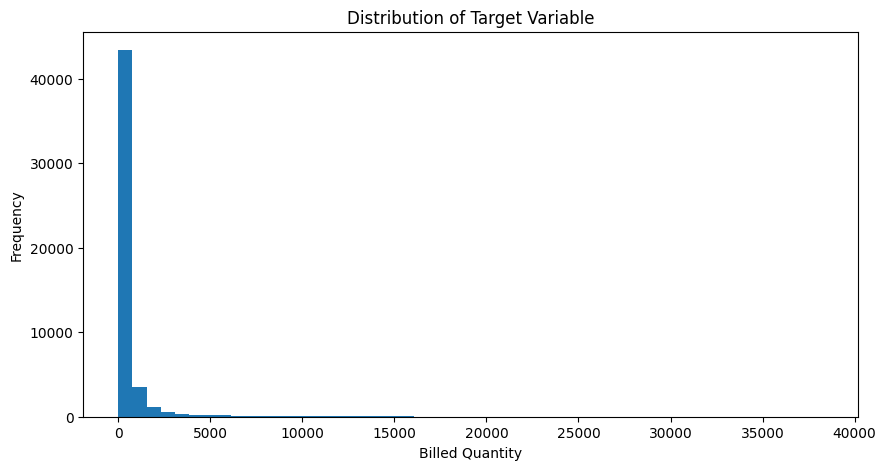

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    Data_Prep['BilledQuantity_lead1'],
    bins=50
)

plt.xlabel("Billed Quantity")

plt.ylabel("Frequency")

plt.title("Distribution of Target Variable")

plt.show()

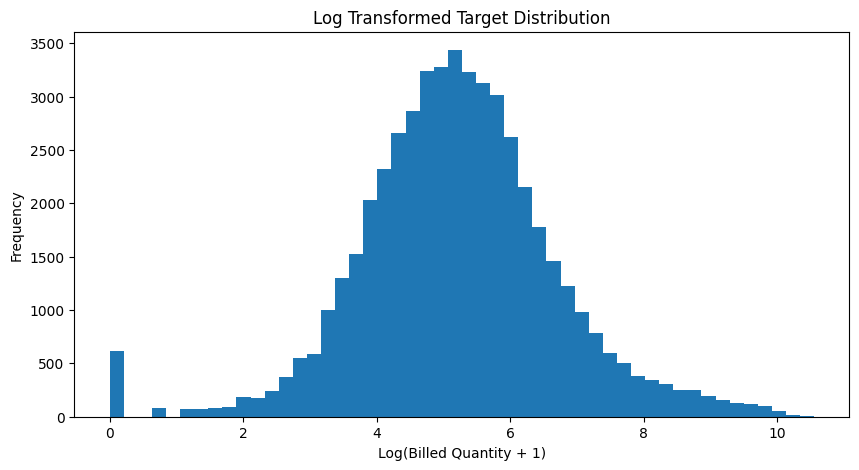

In [59]:
plt.figure(figsize=(10,5))

plt.hist(
    np.log1p(Data_Prep['BilledQuantity_lead1']),
    bins=50
)

plt.xlabel("Log(Billed Quantity + 1)")

plt.ylabel("Frequency")

plt.title("Log Transformed Target Distribution")

plt.show()

## Distribution Insight

The target variable shows a highly right-skewed distribution, where most demand values are concentrated at lower ranges while a smaller number of products exhibit very high demand volumes.

This indicates the presence of:
- demand imbalance
- high-volume outliers
- varying forecasting complexity across products

Due to this behavior, separate analysis for low-volume and high-volume demand patterns was later considered during forecasting evaluation.

# Product Category Filtering

The dataset was specifically filtered for products belonging to the:

`RUNNER`

category.

Runner products represent high-demand and frequently sold materials, making them highly important for demand sensing and forecasting analysis.

Focusing on runner products helps:
- improve forecasting relevance
- reduce intermittent low-demand noise
- analyze stable high-volume demand behavior
- optimize forecasting for critical inventory items

## Filtering Runner Products

In [18]:
Data_Prep=Data_Prep[Data_Prep['Category']=='RUNNER']
Data_Prep

,BilledQuantity_lead1,Period,Material_Region,Month,Year,Region,Category,BilledQuantity_lag0,BilledQuantity_lag1,BilledQuantity_lag2,...,roll_std_3,momentum,cv_3,stock_cover,zero_flag,zero_rate_6,trend_idx,is_period_1,is_period_2,SalesMonth
147285,109,1,PAT_HX00-GQP12V1450N,1,2024,PAT,RUNNER,9,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0,0.000000,0,1,0,2024-01-01
76545,631,1,HUB_FXP5-XP800,1,2024,HUB,RUNNER,571,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0,0.000000,0,1,0,2024-01-01
39042,641,1,CUT_FEK5-EKO60L,1,2024,CUT,RUNNER,571,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0,0.000000,0,1,0,2024-01-01
13041,656,1,BAN_FXL0-12XL14L-A2,1,2024,BAN,RUNNER,526,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0,0.000000,0,1,0,2024-01-01
76518,138,1,HUB_FXP5-XP1500,1,2024,HUB,RUNNER,222,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0,0.000000,0,1,0,2024-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112778,1670,1,KOC_F2W5-48S-TZ5L-B,3,2026,KOC,RUNNER,3675,2883.0,1668.0,...,1047.246389,1.041546,0.378340,0.708454,0,0.000000,52,1,0,2026-03-01
112832,126,1,KOC_F4W0-72S-55LS,3,2026,KOC,RUNNER,77,129.0,58.0,...,38.214308,1.511719,0.447824,0.000000,0,0.000000,52,1,0,2026-03-01
112913,47,1,KOC_F4W0-HX-N55,3,2026,KOC,RUNNER,42,0.0,27.0,...,18.734994,0.000000,0.892143,0.000000,0,0.166667,52,1,0,2026-03-01
112994,45,1,KOC_F4W5-48S-105D31L,3,2026,KOC,RUNNER,107,62.0,53.0,...,4.582576,1.068966,0.079010,0.189655,0,0.000000,52,1,0,2026-03-01


## Filtered Dataset Summary

The filtered dataset now contains only high-demand runner products used for forecasting model training and evaluation.

In [19]:
Data_Prep.shape

Data_Prep['Category'].value_counts()

Category
RUNNER    50571
Name: count, dtype: int64

In [20]:
current_oot_months = sorted(
    Data_Results[
        Data_Results['SalesMonth'] >= date
    ]['SalesMonth'].unique()
)

print("OOT Months:")
print(current_oot_months)

print("\nTotal OOT Months:")
print(len(current_oot_months))

OOT Months:
[Timestamp('2025-10-01 00:00:00'), Timestamp('2025-11-01 00:00:00'), Timestamp('2025-12-01 00:00:00'), Timestamp('2026-01-01 00:00:00'), Timestamp('2026-02-01 00:00:00'), Timestamp('2026-03-01 00:00:00')]

Total OOT Months:
6


In [21]:

Data_Prep['SalesMonth'] = pd.to_datetime(

    dict(
        year=Data_Prep['Year'],
        month=Data_Prep['Month'],
        day=1
    )

)

Data_Prep[
    ['Year', 'Month', 'SalesMonth']
].drop_duplicates().sort_values(
    ['Year', 'Month']
).head(20)

,Year,Month,SalesMonth
147285,2024,1,2024-01-01
123364,2024,2,2024-02-01
85241,2024,3,2024-03-01
1299,2024,4,2024-04-01
134572,2024,5,2024-05-01
118697,2024,6,2024-06-01
5568,2024,7,2024-07-01
76633,2024,8,2024-08-01
61595,2024,9,2024-09-01
163170,2024,10,2024-10-01


# Existing Engineered Features

The dataset already contained multiple engineered forecasting features designed to capture temporal demand behavior and demand stability patterns.

---

## 1. Lag Features

These features capture historical demand values from previous months.

Examples:
- BilledQuantity_lag0
- BilledQuantity_lag1
- BilledQuantity_lag2
- BilledQuantity_lag3

---

## 2. Rolling Statistical Features

These features capture moving demand statistics over rolling windows.

Examples:
- roll_mean_3
- roll_std_3
- cv_3

---

## 3. Trend & Momentum Features

These features help capture growth or decline trends in demand.

Examples:
- momentum
- trend_idx

---

## 4. Demand Stability Features

These features measure demand intermittency and stock behavior.

Examples:
- stock_cover
- zero_flag
- zero_rate_6

---

## 5. Categorical Features

Examples:
- Region
- Category
- Material_Region

---

## 6. Time Features

Examples:
- Month
- Year
- Period
- SalesMonth

In [22]:
important_columns = [

    'Material_Region',
    'SalesMonth',

    'BilledQuantity_lag0',
    'BilledQuantity_lag1',

    'roll_mean_3',
    'roll_std_3',

    'momentum',
    'cv_3',

    'stock_cover',
    'zero_rate_6'

]

Data_Results[
    important_columns
].head()

,Material_Region,SalesMonth,BilledQuantity_lag0,BilledQuantity_lag1,roll_mean_3,roll_std_3,momentum,cv_3,stock_cover,zero_rate_6
0,AHM_F2W0-48S-14L-A2,2024-01-01,232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99657,JAL_F4W5-HXDIN52RMFEFB,2024-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
175068,VIJ_HX00-GQP12V1450N,2024-01-01,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13068,BAN_FXL0-XLTX14,2024-01-01,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
154197,PUN_HX00-GQP12V1450N,2024-01-01,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Selected Features

In [23]:
selected_features = list(
    Data_Prep.iloc[:, 7:-1].columns
)

print("Feature Count:", len(selected_features))

print(selected_features[:10])

Feature Count: 78
['BilledQuantity_lag0', 'BilledQuantity_lag1', 'BilledQuantity_lag2', 'BilledQuantity_lag3', 'BilledQuantity_lag4', 'BilledQuantity_lag5', 'BilledQuantity_lag6', 'BilledQuantity_lag7', 'BilledQuantity_lag8', 'BilledQuantity_lag9']


# XGBoost Forecasting

XGBoost Regressor was used as a gradient boosting forecasting model to capture nonlinear demand behavior and complex feature interactions across material-region combinations.

The XGBoost model was trained using historical demand features, lag variables, rolling statistics, and demand stability indicators.

The workflow inside this section includes:

- Hyperparameter tuning using RandomizedSearchCV
- Final optimized model training
- Out-of-Time forecasting
- Forecast evaluation using SMAPE, RMSE, and WAPE
- Forecast result generation

## XGBoost Training Function

In [24]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_squared_error
)

from xgboost import XGBRegressor
import joblib

def train_and_evaluate(
    df,
    features,
    target_column,
    year_column='SalesMonth'
):

    features = [
        col for col in features
        if col != 'SalesMonth'
    ]

    """
    Train and evaluate a tuned XGBoost model,
    returning DataFrames with actual values
    and predictions.
    """

    # =========================
    # FEATURES & TARGET
    # =========================

    X = df[features]

    y = df[target_column]

    X_full = df.copy()

    # =========================
    # TIME SPLIT
    # =========================

    train_mask = df[year_column] < date

    oot_mask = df[year_column] >= date

    # pre oot data
    X_pre_2024 = (
        X_full.loc[train_mask]
        .sort_values(
            ['Material_Region', year_column]
        )
    )

    y_pre_2024 = y.loc[X_pre_2024.index]

    # oot data
    X_out_of_time = (
        X_full.loc[oot_mask]
        .sort_values(
            ['Material_Region', year_column]
        )
    )

    y_out_of_time = y.loc[
        X_out_of_time.index
    ]

    # =========================
    # TRAIN TEST SPLIT
    # =========================

    X_train, X_test, y_train, y_test = (

        train_test_split(
            X_pre_2024,
            y_pre_2024,
            test_size=0.25,
            shuffle=False
        )
    )

    # =========================
    # BASE MODEL
    # =========================

    xgb_base = XGBRegressor(

        objective='reg:squarederror',

        random_state=42,

        n_jobs=-1
    )
    # HYPERPARAMETER SPACE
    
    param_grid = {

        'n_estimators': [100, 200, 300],

        'max_depth': [4, 6, 8, 10],

        'learning_rate': [0.01, 0.03, 0.05, 0.1],

        'subsample': [0.7, 0.8, 0.9, 1.0],

        'colsample_bytree': [0.7, 0.8, 0.9, 1.0],

        'min_child_weight': [1, 3, 5]

    }

    # RANDOMIZED SEARCH

    random_search = RandomizedSearchCV(

        estimator=xgb_base,
        param_distributions=param_grid,
        n_iter=20,
        scoring='neg_mean_absolute_error',
        cv=3,
        verbose=2,
        random_state=42,
        n_jobs=-1

    )

    # HYPERTUNE

    random_search.fit(
        X_train[features],
        y_train
    )

    # BEST MODEL

    model = random_search.best_estimator_

    print("\nBest Parameters:")
    print(random_search.best_params_)

    # TRAIN MODEL

    model.fit(
        X_train[features],
        y_train
    )

    # SAVE MODEL

    joblib.dump(
        model,
        "M1_xgboost_model_RUNNER.pkl"
    )

    # PREDICTIONS

    y_train_pred = model.predict(
        X_train[features]
    )

    y_test_pred = model.predict(
        X_test[features]
    )

    y_out_of_time_pred = model.predict(
        X_out_of_time[features]
    )

    # REMOVE NEGATIVES
   
    y_train_pred = np.maximum(
        0,
        y_train_pred
    )

    y_test_pred = np.maximum(
        0,
        y_test_pred
    )

    y_out_of_time_pred = np.maximum(
        0,
        y_out_of_time_pred
    )

    # METRIC FUNCTION

    def calculate_metrics(
        y_true,
        y_pred
    ):

        mape = (
            mean_absolute_percentage_error(
                y_true,
                y_pred
            )
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        )

        wape = (
            np.sum(
                np.abs(y_true - y_pred)
            )
            /
            np.sum(np.abs(y_true))
            if np.sum(np.abs(y_true)) != 0
            else np.nan
        )

        return mape, rmse, wape

    # TRAIN METRICS
    
    train_mape, train_rmse, train_wape = (

        calculate_metrics(
            y_train,
            y_train_pred
        )
    )

    print(
        f"Training Set - "
        f"MAPE: {train_mape:.4f}, "
        f"RMSE: {train_rmse:.4f}, "
        f"WAPE: {train_wape:.4f}"
    )
   
    # TEST METRICS
    
    test_mape, test_rmse, test_wape = (

        calculate_metrics(
            y_test,
            y_test_pred
        )
    )

    print(
        f"Test Set - "
        f"MAPE: {test_mape:.4f}, "
        f"RMSE: {test_rmse:.4f}, "
        f"WAPE: {test_wape:.4f}"
    )

    # OOT METRICS

    oot_mape, oot_rmse, oot_wape = (

        calculate_metrics(
            y_out_of_time,
            y_out_of_time_pred
        )
    )

    print(
        f"Out-of-Time Set - "
        f"MAPE: {oot_mape:.4f}, "
        f"RMSE: {oot_rmse:.4f}, "
        f"WAPE: {oot_wape:.4f}"
    )

    # TRAIN RESULTS

    df_train_results = X_train.copy()

    df_train_results[
        target_column + '_actual'
    ] = y_train

    df_train_results[
        target_column + '_predicted'
    ] = y_train_pred

    df_test_results = X_test.copy()

    df_test_results[
        target_column + '_actual'
    ] = y_test

    df_test_results[
        target_column + '_predicted'
    ] = y_test_pred


    df_out_of_time_results = (
        X_out_of_time.copy()
    )

    df_out_of_time_results[
        target_column + '_actual'
    ] = y_out_of_time

    df_out_of_time_results[
        target_column + '_predicted'
    ] = y_out_of_time_pred

    df_out_of_time_results[
        'xgb_pred'
    ] = y_out_of_time_pred

    return (
        df_train_results,
        df_test_results,
        df_out_of_time_results
    )

(
    df_train_results,
    df_test_results,
    df_out_of_time_results
) = train_and_evaluate(
    Data_Prep,
    selected_features,
    target_column='BilledQuantity_lead1'
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters:
{'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
Training Set - MAPE: 4476600120770560.0000, RMSE: 96.0642, WAPE: 0.0892
Test Set - MAPE: 2347684421697536.0000, RMSE: 459.2108, WAPE: 0.1823
Out-of-Time Set - MAPE: 4422815319064576.0000, RMSE: 511.8592, WAPE: 0.2103


In [25]:
df_out_of_time_results

,BilledQuantity_lead1,Period,Material_Region,Month,Year,Region,Category,BilledQuantity_lag0,BilledQuantity_lag1,BilledQuantity_lag2,...,stock_cover,zero_flag,zero_rate_6,trend_idx,is_period_1,is_period_2,SalesMonth,BilledQuantity_lead1_actual,BilledQuantity_lead1_predicted,xgb_pred
210,9104,1,AHM_F2W5-48S-TZ4A,10,2025,AHM,RUNNER,5117,9412.0,1443.0,...,1.860846,0,0.0,42,1,0,2025-10-01,9104,9498.983398,9498.983398
211,5859,1,AHM_F2W5-48S-TZ4A,11,2025,AHM,RUNNER,6224,9104.0,5117.0,...,0.555748,0,0.0,44,1,0,2025-11-01,5859,8472.745117,8472.745117
212,7795,1,AHM_F2W5-48S-TZ4A,12,2025,AHM,RUNNER,11391,5859.0,6224.0,...,0.271298,0,0.0,46,1,0,2025-12-01,7795,6845.666504,6845.666504
213,10904,1,AHM_F2W5-48S-TZ4A,1,2026,AHM,RUNNER,5233,7795.0,11391.0,...,0.859453,0,0.0,48,1,0,2026-01-01,10904,8936.668945,8936.668945
214,10570,1,AHM_F2W5-48S-TZ4A,2,2026,AHM,RUNNER,3247,10904.0,5233.0,...,1.151262,0,0.0,50,1,0,2026-02-01,10570,11934.440430,11934.440430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175468,25,1,VIJ_KX00-024EXIDEN020,11,2025,VIJ,RUNNER,18,34.0,41.0,...,2.607477,0,0.0,44,1,0,2025-11-01,25,54.799709,54.799709
175469,27,1,VIJ_KX00-024EXIDEN020,12,2025,VIJ,RUNNER,24,25.0,18.0,...,2.649351,0,0.0,46,1,0,2025-12-01,27,53.316277,53.316277
175470,24,1,VIJ_KX00-024EXIDEN020,1,2026,VIJ,RUNNER,17,27.0,24.0,...,1.539474,0,0.0,48,1,0,2026-01-01,24,51.893829,51.893829
175471,23,1,VIJ_KX00-024EXIDEN020,2,2026,VIJ,RUNNER,27,24.0,17.0,...,6.617647,0,0.0,50,1,0,2026-02-01,23,39.568710,39.568710


## Out-of-Time (OOT) Validation

In [26]:
df_out_of_time_results_all = (
    df_out_of_time_results.copy()
)
oft = df_out_of_time_results_all.copy()

oft['Model_Number'] = "M1_xgboost_model"

oft_final = oft.copy()

oft_final

,BilledQuantity_lead1,Period,Material_Region,Month,Year,Region,Category,BilledQuantity_lag0,BilledQuantity_lag1,BilledQuantity_lag2,...,zero_flag,zero_rate_6,trend_idx,is_period_1,is_period_2,SalesMonth,BilledQuantity_lead1_actual,BilledQuantity_lead1_predicted,xgb_pred,Model_Number
210,9104,1,AHM_F2W5-48S-TZ4A,10,2025,AHM,RUNNER,5117,9412.0,1443.0,...,0,0.0,42,1,0,2025-10-01,9104,9498.983398,9498.983398,M1_xgboost_model
211,5859,1,AHM_F2W5-48S-TZ4A,11,2025,AHM,RUNNER,6224,9104.0,5117.0,...,0,0.0,44,1,0,2025-11-01,5859,8472.745117,8472.745117,M1_xgboost_model
212,7795,1,AHM_F2W5-48S-TZ4A,12,2025,AHM,RUNNER,11391,5859.0,6224.0,...,0,0.0,46,1,0,2025-12-01,7795,6845.666504,6845.666504,M1_xgboost_model
213,10904,1,AHM_F2W5-48S-TZ4A,1,2026,AHM,RUNNER,5233,7795.0,11391.0,...,0,0.0,48,1,0,2026-01-01,10904,8936.668945,8936.668945,M1_xgboost_model
214,10570,1,AHM_F2W5-48S-TZ4A,2,2026,AHM,RUNNER,3247,10904.0,5233.0,...,0,0.0,50,1,0,2026-02-01,10570,11934.440430,11934.440430,M1_xgboost_model
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175468,25,1,VIJ_KX00-024EXIDEN020,11,2025,VIJ,RUNNER,18,34.0,41.0,...,0,0.0,44,1,0,2025-11-01,25,54.799709,54.799709,M1_xgboost_model
175469,27,1,VIJ_KX00-024EXIDEN020,12,2025,VIJ,RUNNER,24,25.0,18.0,...,0,0.0,46,1,0,2025-12-01,27,53.316277,53.316277,M1_xgboost_model
175470,24,1,VIJ_KX00-024EXIDEN020,1,2026,VIJ,RUNNER,17,27.0,24.0,...,0,0.0,48,1,0,2026-01-01,24,51.893829,51.893829,M1_xgboost_model
175471,23,1,VIJ_KX00-024EXIDEN020,2,2026,VIJ,RUNNER,27,24.0,17.0,...,0,0.0,50,1,0,2026-02-01,23,39.568710,39.568710,M1_xgboost_model


# Monthly Demand Trend

The following chart visualizes the monthly demand trend across the forecasting timeline.

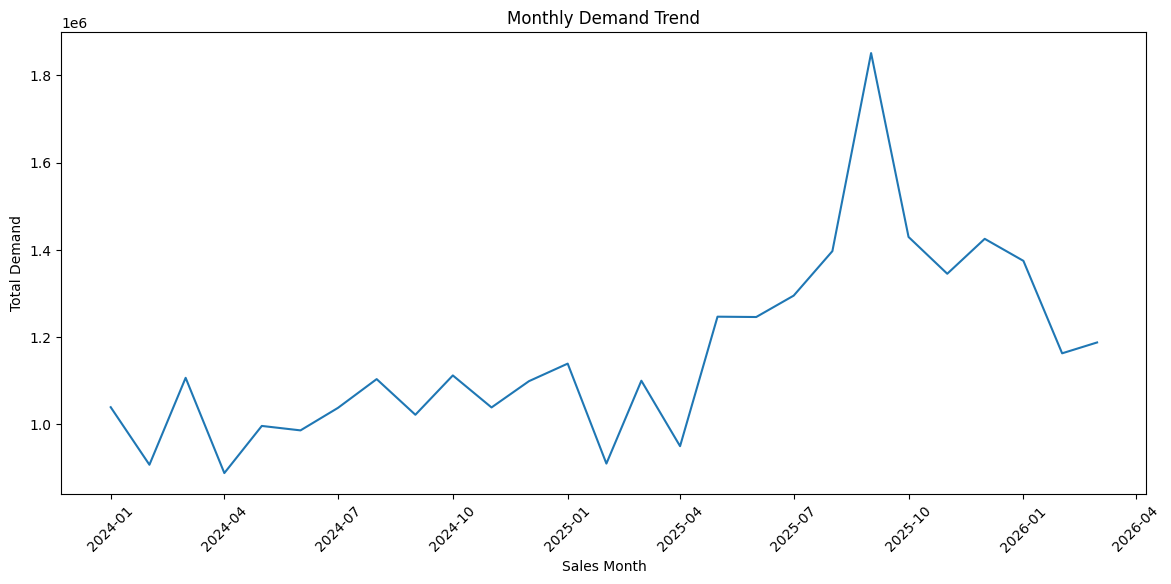

In [60]:
monthly_sales = (
    Data_Prep
    .groupby('SalesMonth')[
        'BilledQuantity_lead1'
    ]
    .sum()
)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values
)

plt.xlabel("Sales Month")

plt.ylabel("Total Demand")

plt.title("Monthly Demand Trend")

plt.xticks(rotation=45)

plt.show()

## XGBoost Model Evaluation

The model performance was evaluated using:

- SMAPE
- RMSE
- WAPE

The model demonstrated strong forecasting capability for high-volume products and comparatively stable forecasting performance across multiple regions.

In [27]:

Final_M1 = df_out_of_time_results_all[
    [
        'Material_Region',
        'Region',
        'SalesMonth',
        'BilledQuantity_lead1',
        'BilledQuantity_lead1_predicted'
    ]
].copy()


Final_M1['BilledQuantity_lead1_predicted'] = (
    Final_M1['BilledQuantity_lead1_predicted']
    .apply(lambda x: x if x >= 5 else 0)
)


Final_M1['SMAPE1'] = np.abs(
    Final_M1['BilledQuantity_lead1']
    - Final_M1['BilledQuantity_lead1_predicted']
)

Final_M1['SMAPE2'] = (
    (
        np.abs(Final_M1['BilledQuantity_lead1']) +
        np.abs(Final_M1['BilledQuantity_lead1_predicted'])
    ) / 2
)

Final_M1['SMAPE'] = np.where(
    Final_M1['SMAPE2'] == 0,
    0,
    (
        Final_M1['SMAPE1']
        /
        Final_M1['SMAPE2']
    ) * 100
)

Final_M1.fillna(0, inplace=True)

Final_M1['Model_Number'] = (
    "M1_xgboost_model"
)


all_model_results = pd.concat(
    [
        all_model_results,
        Final_M1
    ],
    ignore_index=True
)

print(
    Final_M1['Material_Region'].nunique()
)

Final_M1

1873


,Material_Region,Region,SalesMonth,BilledQuantity_lead1,BilledQuantity_lead1_predicted,SMAPE1,SMAPE2,SMAPE,Model_Number
210,AHM_F2W5-48S-TZ4A,AHM,2025-10-01,9104,9498.983398,394.983398,9301.491699,4.246452,M1_xgboost_model
211,AHM_F2W5-48S-TZ4A,AHM,2025-11-01,5859,8472.745117,2613.745117,7165.872559,36.474904,M1_xgboost_model
212,AHM_F2W5-48S-TZ4A,AHM,2025-12-01,7795,6845.666504,949.333496,7320.333252,12.968446,M1_xgboost_model
213,AHM_F2W5-48S-TZ4A,AHM,2026-01-01,10904,8936.668945,1967.331055,9920.334473,19.831298,M1_xgboost_model
214,AHM_F2W5-48S-TZ4A,AHM,2026-02-01,10570,11934.440430,1364.440430,11252.220215,12.125966,M1_xgboost_model
...,...,...,...,...,...,...,...,...,...
175468,VIJ_KX00-024EXIDEN020,VIJ,2025-11-01,25,54.799709,29.799709,39.899855,74.686260,M1_xgboost_model
175469,VIJ_KX00-024EXIDEN020,VIJ,2025-12-01,27,53.316277,26.316277,40.158138,65.531615,M1_xgboost_model
175470,VIJ_KX00-024EXIDEN020,VIJ,2026-01-01,24,51.893829,27.893829,37.946915,73.507503,M1_xgboost_model
175471,VIJ_KX00-024EXIDEN020,VIJ,2026-02-01,23,39.568710,16.568710,31.284355,52.961649,M1_xgboost_model


# High Accuracy Forecast Analysis

To identify highly reliable forecasts, records with:

SMAPE < 20%

were filtered from the XGBoost forecasting results.

This analysis helps evaluate:
- stable forecasting regions
- well-performing material groups
- low-error prediction patterns

The filtered dataframe represents high-confidence forecasts generated by the model.

In [28]:

xgb_region_smape = (
    Final_M1
    .groupby(
        ['Material_Region'],
        as_index=False
    )['SMAPE']
    .max()
    .sort_values(by='SMAPE')
)


xgb_good_regions = (
    xgb_region_smape[
        xgb_region_smape['SMAPE'] < 20
    ]
)

xgb_good_regions

,Material_Region,SMAPE
454,COI_FXL5-XLTZ4A,9.841941
1425,MUM_FXP5-XP800,14.515737
704,GUR_FXP5-XP1000,15.030241
1435,NAG_FAT5-24S-60L,15.047318
844,HYD_FEK5-EKO50L,15.138207
1819,VIJ_FEK0-EKO40L,15.259783
355,CHE_FXP0-XP1300,15.744843
1854,VIJ_FXL5-XLTZ5A,16.159663
1129,JAL_FXL5-12XL5L-B,16.646726
573,DEL_FXL5-XLTZ4A,17.841598




Forecasts with high SMAPE values were separately analyzed to identify:
- highly volatile demand patterns
- intermittent demand behavior
- difficult-to-predict material groups

# Random Forest Forecasting Model

The Random Forest model was trained using historical demand features, lag variables, rolling statistics, and demand stability indicators.

The workflow inside this section includes:

- Hyperparameter tuning using RandomizedSearchCV
- Final optimized model training
- Out-of-Time forecasting
- Forecast evaluation using SMAPE, RMSE, and WAPE
- Forecast result generation

## Random Forest Training Function

In [29]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.metrics import (
    mean_squared_error
)

from sklearn.ensemble import (
    RandomForestRegressor
)

import joblib


def train_and_evaluate_rf(
    df,
    features,
    target_column,
    year_column='SalesMonth'
):

    try:

        # =========================
        # REMOVE DATETIME FEATURE
        # =========================

        features = [
            col for col in features
            if col != 'SalesMonth'
        ]

        # =========================
        # FEATURES & TARGET
        # =========================

        X = df[features]

        y = df[target_column]

        X_full = df.copy()


        train_mask = (
            df[year_column] < date
        )

        oot_mask = (
            df[year_column] >= date
        )

        # train data
        X_pre_oot = (
            X_full.loc[train_mask]
            .sort_values(
                ['Material_Region', year_column]
            )
        )

        y_pre_oot = y.loc[
            X_pre_oot.index
        ]

        # oot data
        X_out_of_time = (
            X_full.loc[oot_mask]
            .sort_values(
                ['Material_Region', year_column]
            )
        )

        y_out_of_time = y.loc[
            X_out_of_time.index
        ]

        X_train, X_test, y_train, y_test = (
            train_test_split(
                X_pre_oot,
                y_pre_oot,
                test_size=0.25,
                shuffle=False
            )
        )

        rf_base = RandomForestRegressor(

            random_state=42,

            n_jobs=-1

        )

        param_grid = {

            'n_estimators': [100, 200, 300],

            'max_depth': [5, 10, 15, 20, None],

            'min_samples_split': [2, 5, 10],

            'min_samples_leaf': [1, 2, 4],

            'max_features': ['sqrt', 'log2']

        }

        random_search = RandomizedSearchCV(

            estimator=rf_base,

            param_distributions=param_grid,

            n_iter=20,

            scoring='neg_mean_absolute_error',

            cv=3,

            verbose=2,

            random_state=42,

            n_jobs=-1

        )

        random_search.fit(

            X_train[features],

            y_train

        )

        model = random_search.best_estimator_

        print("\nBest Parameters:")
        print(random_search.best_params_)

        joblib.dump(

            model,

            "M2_rf_model_RUNNER.pkl"
        )


        y_train_pred = model.predict(

            X_train[features]

        )

        y_test_pred = model.predict(

            X_test[features]

        )

        y_out_of_time_pred = model.predict(

            X_out_of_time[features]

        )

        # =========================
        # REMOVE NEGATIVES
        # =========================

        y_train_pred = np.maximum(
            0,
            y_train_pred
        )

        y_test_pred = np.maximum(
            0,
            y_test_pred
        )

        y_out_of_time_pred = np.maximum(
            0,
            y_out_of_time_pred
        )

        # =========================
        # METRICS
        # =========================

        def calculate_metrics(
            y_true,
            y_pred
        ):
            epsilon = 1

            smape = np.mean(

                (
                    np.abs(y_true - y_pred)

                    /
                    (
                        (
                            np.abs(y_true)
                            +
                            np.abs(y_pred)
                        ) / 2
                        + epsilon
                    )
                )
            ) * 100

            rmse = np.sqrt(

                mean_squared_error(
                    y_true,
                    y_pred
                )

            )

            wape = (

                np.sum(
                    np.abs(y_true - y_pred)
                )

                /

                np.sum(np.abs(y_true))

                if np.sum(np.abs(y_true)) != 0

                else np.nan

            )

            return smape, rmse, wape

        train_smape, train_rmse, train_wape = (

            calculate_metrics(
                y_train,
                y_train_pred
            )

        )

        print(

            f"Training Set - "
            f"SMAPE: {train_smape:.4f}, "
            f"RMSE: {train_rmse:.4f}, "
            f"WAPE: {train_wape:.4f}"

        )

        test_smape, test_rmse, test_wape = (

            calculate_metrics(
                y_test,
                y_test_pred
            )
        )
        print(

            f"Test Set - "
            f"SMAPE: {test_smape:.4f}, "
            f"RMSE: {test_rmse:.4f}, "
            f"WAPE: {test_wape:.4f}"

        )

        oot_smape, oot_rmse, oot_wape = (

            calculate_metrics(
                y_out_of_time,
                y_out_of_time_pred
            )

        )

        print(

            f"Out-of-Time Set - "
            f"SMAPE: {oot_smape:.4f}, "
            f"RMSE: {oot_rmse:.4f}, "
            f"WAPE: {oot_wape:.4f}"

        )

        rf_train_results = (
            X_train.copy()
        )

        rf_train_results[
            target_column + '_actual'
        ] = y_train

        rf_train_results[
            target_column + '_predicted'
        ] = y_train_pred

        rf_test_results = (
            X_test.copy()
        )

        rf_test_results[
            target_column + '_actual'
        ] = y_test

        rf_test_results[
            target_column + '_predicted'
        ] = y_test_pred

        #
        rf_oot_results = (
            X_out_of_time.copy()
        )

        rf_oot_results[
            target_column + '_actual'
        ] = y_out_of_time

        rf_oot_results[
            target_column + '_predicted'
        ] = y_out_of_time_pred

        rf_oot_results[
            'rf_pred'
        ] = y_out_of_time_pred

        return (

            rf_train_results,

            rf_test_results,

            rf_oot_results

        )

    except Exception as e:

        print(
            f"An error occurred: {e}"
        )

        return None, None, None

(
    rf_train_results,
    rf_test_results,
    rf_oot_results
) = train_and_evaluate_rf(

    Data_Prep,

    selected_features,

    target_column='BilledQuantity_lead1'
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Training Set - SMAPE: 16.9854, RMSE: 201.6985, WAPE: 0.0988
Test Set - SMAPE: 28.4490, RMSE: 521.8135, WAPE: 0.2139
Out-of-Time Set - SMAPE: 33.3549, RMSE: 520.7179, WAPE: 0.2228


## Out-of-Time (OOT) Validation

In [30]:
# =========================
# STORE RF OUTPUT
# =========================

rf_out_of_time_results_all = (
    rf_oot_results.copy()
)

# =========================
# ADD MODEL NAME
# =========================

rf_oft = rf_out_of_time_results_all.copy()

rf_oft['Model_Number'] = (
    "M2_rf_model"
)

# =========================
# APPEND TO MASTER
# =========================

oft_final = pd.concat(
    [
        oft_final,
        rf_oft
    ],
    ignore_index=True
)

rf_oft


,BilledQuantity_lead1,Period,Material_Region,Month,Year,Region,Category,BilledQuantity_lag0,BilledQuantity_lag1,BilledQuantity_lag2,...,zero_flag,zero_rate_6,trend_idx,is_period_1,is_period_2,SalesMonth,BilledQuantity_lead1_actual,BilledQuantity_lead1_predicted,rf_pred,Model_Number
210,9104,1,AHM_F2W5-48S-TZ4A,10,2025,AHM,RUNNER,5117,9412.0,1443.0,...,0,0.0,42,1,0,2025-10-01,9104,8895.978008,8895.978008,M2_rf_model
211,5859,1,AHM_F2W5-48S-TZ4A,11,2025,AHM,RUNNER,6224,9104.0,5117.0,...,0,0.0,44,1,0,2025-11-01,5859,8614.974562,8614.974562,M2_rf_model
212,7795,1,AHM_F2W5-48S-TZ4A,12,2025,AHM,RUNNER,11391,5859.0,6224.0,...,0,0.0,46,1,0,2025-12-01,7795,7892.644750,7892.644750,M2_rf_model
213,10904,1,AHM_F2W5-48S-TZ4A,1,2026,AHM,RUNNER,5233,7795.0,11391.0,...,0,0.0,48,1,0,2026-01-01,10904,8670.800060,8670.800060,M2_rf_model
214,10570,1,AHM_F2W5-48S-TZ4A,2,2026,AHM,RUNNER,3247,10904.0,5233.0,...,0,0.0,50,1,0,2026-02-01,10570,9773.282361,9773.282361,M2_rf_model
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175468,25,1,VIJ_KX00-024EXIDEN020,11,2025,VIJ,RUNNER,18,34.0,41.0,...,0,0.0,44,1,0,2025-11-01,25,40.695073,40.695073,M2_rf_model
175469,27,1,VIJ_KX00-024EXIDEN020,12,2025,VIJ,RUNNER,24,25.0,18.0,...,0,0.0,46,1,0,2025-12-01,27,36.176532,36.176532,M2_rf_model
175470,24,1,VIJ_KX00-024EXIDEN020,1,2026,VIJ,RUNNER,17,27.0,24.0,...,0,0.0,48,1,0,2026-01-01,24,35.366996,35.366996,M2_rf_model
175471,23,1,VIJ_KX00-024EXIDEN020,2,2026,VIJ,RUNNER,27,24.0,17.0,...,0,0.0,50,1,0,2026-02-01,23,25.357194,25.357194,M2_rf_model


In [31]:
df_out_of_time_results

,BilledQuantity_lead1,Period,Material_Region,Month,Year,Region,Category,BilledQuantity_lag0,BilledQuantity_lag1,BilledQuantity_lag2,...,stock_cover,zero_flag,zero_rate_6,trend_idx,is_period_1,is_period_2,SalesMonth,BilledQuantity_lead1_actual,BilledQuantity_lead1_predicted,xgb_pred
210,9104,1,AHM_F2W5-48S-TZ4A,10,2025,AHM,RUNNER,5117,9412.0,1443.0,...,1.860846,0,0.0,42,1,0,2025-10-01,9104,9498.983398,9498.983398
211,5859,1,AHM_F2W5-48S-TZ4A,11,2025,AHM,RUNNER,6224,9104.0,5117.0,...,0.555748,0,0.0,44,1,0,2025-11-01,5859,8472.745117,8472.745117
212,7795,1,AHM_F2W5-48S-TZ4A,12,2025,AHM,RUNNER,11391,5859.0,6224.0,...,0.271298,0,0.0,46,1,0,2025-12-01,7795,6845.666504,6845.666504
213,10904,1,AHM_F2W5-48S-TZ4A,1,2026,AHM,RUNNER,5233,7795.0,11391.0,...,0.859453,0,0.0,48,1,0,2026-01-01,10904,8936.668945,8936.668945
214,10570,1,AHM_F2W5-48S-TZ4A,2,2026,AHM,RUNNER,3247,10904.0,5233.0,...,1.151262,0,0.0,50,1,0,2026-02-01,10570,11934.440430,11934.440430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175468,25,1,VIJ_KX00-024EXIDEN020,11,2025,VIJ,RUNNER,18,34.0,41.0,...,2.607477,0,0.0,44,1,0,2025-11-01,25,54.799709,54.799709
175469,27,1,VIJ_KX00-024EXIDEN020,12,2025,VIJ,RUNNER,24,25.0,18.0,...,2.649351,0,0.0,46,1,0,2025-12-01,27,53.316277,53.316277
175470,24,1,VIJ_KX00-024EXIDEN020,1,2026,VIJ,RUNNER,17,27.0,24.0,...,1.539474,0,0.0,48,1,0,2026-01-01,24,51.893829,51.893829
175471,23,1,VIJ_KX00-024EXIDEN020,2,2026,VIJ,RUNNER,27,24.0,17.0,...,6.617647,0,0.0,50,1,0,2026-02-01,23,39.568710,39.568710


The forecasting performance was evaluated using:

- SMAPE
- RMSE
- WAPE

These metrics help measure forecasting accuracy, error magnitude, and weighted forecasting deviation.

## Random Forest Model Evaluation

The model performance was evaluated using:

- SMAPE
- RMSE
- WAPE

The model demonstrated strong forecasting capability for high-volume products and comparatively stable forecasting performance across multiple regions.

In [32]:

Final_M2 = rf_out_of_time_results_all[
    [
        'Material_Region',
        'Region',
        'SalesMonth',
        'BilledQuantity_lead1',
        'BilledQuantity_lead1_predicted'
    ]
].copy()

Final_M2['BilledQuantity_lead1_predicted'] = (
    Final_M2['BilledQuantity_lead1_predicted']
    .apply(lambda x: x if x >= 5 else 0)
)

Final_M2['SMAPE1'] = np.abs(
    Final_M2['BilledQuantity_lead1']
    - Final_M2['BilledQuantity_lead1_predicted']
)

Final_M2['SMAPE2'] = (
    (
        np.abs(Final_M2['BilledQuantity_lead1']) +
        np.abs(Final_M2['BilledQuantity_lead1_predicted'])
    ) / 2
)

Final_M2['SMAPE'] = np.where(
    Final_M2['SMAPE2'] == 0,
    0,
    (
        Final_M2['SMAPE1']
        /
        Final_M2['SMAPE2']
    ) * 100
)

Final_M2.fillna(0, inplace=True)

Final_M2['Model_Number'] = (
    'M2_random_forest_model'
)


all_model_results = pd.concat(
    [
        all_model_results,
        Final_M2
    ],
    ignore_index=True
)

Final_M2

,Material_Region,Region,SalesMonth,BilledQuantity_lead1,BilledQuantity_lead1_predicted,SMAPE1,SMAPE2,SMAPE,Model_Number
210,AHM_F2W5-48S-TZ4A,AHM,2025-10-01,9104,8895.978008,208.021992,8999.989004,2.311358,M2_random_forest_model
211,AHM_F2W5-48S-TZ4A,AHM,2025-11-01,5859,8614.974562,2755.974562,7236.987281,38.081794,M2_random_forest_model
212,AHM_F2W5-48S-TZ4A,AHM,2025-12-01,7795,7892.644750,97.644750,7843.822375,1.244862,M2_random_forest_model
213,AHM_F2W5-48S-TZ4A,AHM,2026-01-01,10904,8670.800060,2233.199940,9787.400030,22.817091,M2_random_forest_model
214,AHM_F2W5-48S-TZ4A,AHM,2026-02-01,10570,9773.282361,796.717639,10171.641181,7.832734,M2_random_forest_model
...,...,...,...,...,...,...,...,...,...
175468,VIJ_KX00-024EXIDEN020,VIJ,2025-11-01,25,40.695073,15.695073,32.847536,47.781583,M2_random_forest_model
175469,VIJ_KX00-024EXIDEN020,VIJ,2025-12-01,27,36.176532,9.176532,31.588266,29.050445,M2_random_forest_model
175470,VIJ_KX00-024EXIDEN020,VIJ,2026-01-01,24,35.366996,11.366996,29.683498,38.293991,M2_random_forest_model
175471,VIJ_KX00-024EXIDEN020,VIJ,2026-02-01,23,25.357194,2.357194,24.178597,9.749095,M2_random_forest_model


## Random Forest Forecast Results

In [33]:
# =========================
# RF GOOD REGIONS
# =========================

Lessthan30_2 = (
    Final_M2
    .groupby(
        ['Material_Region'],
        as_index=False
    )['SMAPE']
    .max()
)

Lessthan30_2 = (
    Lessthan30_2[
        Lessthan30_2['SMAPE'] <= 20
    ]
)

Lessthan30_2['Model_Number'] = (
    'M2_random_forest_model'
)

Lessthan30_2

,Material_Region,SMAPE,Model_Number
44,AHM_FEG5-DRIVE80RF,16.021466,M2_random_forest_model
160,BAN_FXL5-12XL5L-B,16.221695,M2_random_forest_model
196,CAL_FAT5-24S-32R,15.183446,M2_random_forest_model
262,CAL_FXL0-XLTZ7,19.999371,M2_random_forest_model
265,CAL_FXL5-12XL5L-B,18.903477,M2_random_forest_model
291,CHE_F2W5-48S-TZ5L-B,13.991649,M2_random_forest_model
298,CHE_F4W5-66S-38B20L,16.394950,M2_random_forest_model
327,CHE_FML5-ML38B20L,15.980391,M2_random_forest_model
342,CHE_FTK5-42S-130R,15.782238,M2_random_forest_model
346,CHE_FTK5-42S-88L,19.312270,M2_random_forest_model


The following dataframe contains:

- Actual demand values
- Forecasted demand values
- Out-of-Time predictions
- Forecasting error metrics

This output was later used for model comparison and stacking ensemble forecasting.

# LightGBM Forecasting Model

The LightGBM model was trained using historical demand features, lag variables, rolling statistics, and demand stability indicators.

The workflow inside this section includes:

- Hyperparameter tuning using RandomizedSearchCV
- Final optimized model training
- Out-of-Time forecasting
- Forecast evaluation using SMAPE, RMSE, and WAPE
- Forecast result generation

## LightGBM Training Function

In [34]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.metrics import (
    mean_squared_error
)

from lightgbm import (
    LGBMRegressor
)

import joblib


def train_and_evaluate_lgbm(
    df,
    features,
    target_column,
    year_column='SalesMonth'
):

    try:

        # =========================
        # REMOVE DATETIME FEATURE
        # =========================

        features = [
            col for col in features
            if col != 'SalesMonth'
        ]

        # =========================
        # FULL DATA
        # =========================

        X_full = df.copy()

        y = df[target_column]

        train_mask = (
            X_full[year_column] < date
        )

        oot_mask = (
            X_full[year_column] >= date
        )

        # pre oot
        X_pre_oot = (
            X_full.loc[train_mask]
            .sort_values(
                ['Material_Region', year_column]
            )
        )

        y_pre_oot = y.loc[
            X_pre_oot.index
        ]

        # oot
        X_out_of_time = (
            X_full.loc[oot_mask]
            .sort_values(
                ['Material_Region', year_column]
            )
        )

        y_out_of_time = y.loc[
            X_out_of_time.index
        ]

        X_train, X_test, y_train, y_test = (
            train_test_split(
                X_pre_oot,
                y_pre_oot,
                test_size=0.25,
                shuffle=False
            )
        )

        lgbm_base = LGBMRegressor(

            random_state=42,

            verbose=-1

        )

        param_grid = {

            'n_estimators': [100, 200, 300],

            'learning_rate': [
                0.01,
                0.03,
                0.05,
                0.1
            ],

            'max_depth': [
                5,
                10,
                15,
                -1
            ],

            'num_leaves': [
                20,
                31,
                50,
                70
            ],

            'subsample': [
                0.6,
                0.8,
                1.0
            ],

            'colsample_bytree': [
                0.6,
                0.8,
                1.0
            ],

            'min_child_samples': [
                10,
                20,
                30
            ]

        }

        random_search = RandomizedSearchCV(

            estimator=lgbm_base,

            param_distributions=param_grid,

            n_iter=20,

            scoring='neg_mean_absolute_error',

            cv=3,

            verbose=2,

            random_state=42,

            n_jobs=-1

        )

        random_search.fit(

            X_train[features],

            y_train

        )


        model = random_search.best_estimator_

        print("\nBest Parameters:")
        print(random_search.best_params_)

        joblib.dump(
            model,
            'M3_lightgbm_model_RUNNER.pkl'
        )

        y_train_pred = model.predict(
            X_train[features]
        )

        y_test_pred = model.predict(
            X_test[features]
        )

        y_out_of_time_pred = model.predict(
            X_out_of_time[features]
        )

        y_train_pred = np.maximum(
            0,
            y_train_pred
        )

        y_test_pred = np.maximum(
            0,
            y_test_pred
        )

        y_out_of_time_pred = np.maximum(
            0,
            y_out_of_time_pred
        )

        def calculate_metrics(
            y_true,
            y_pred
        ):

            epsilon = 1

            smape = np.mean(
                (
                    np.abs(y_true - y_pred)
                    /
                    (
                        (
                            np.abs(y_true)
                            +
                            np.abs(y_pred)
                        ) / 2
                        + epsilon
                    )
                )
            ) * 100

            rmse = np.sqrt(
                mean_squared_error(
                    y_true,
                    y_pred
                )
            )

            wape = (
                np.sum(
                    np.abs(y_true - y_pred)
                )
                /
                np.sum(np.abs(y_true))
                if np.sum(np.abs(y_true)) != 0
                else np.nan
            )

            return smape, rmse, wape

        train_metrics = calculate_metrics(
            y_train,
            y_train_pred
        )

        print(
            f"Training Set - "
            f"SMAPE: {train_metrics[0]:.4f}, "
            f"RMSE: {train_metrics[1]:.4f}, "
            f"WAPE: {train_metrics[2]:.4f}"
        )

        test_metrics = calculate_metrics(
            y_test,
            y_test_pred
        )

        print(
            f"Test Set - "
            f"SMAPE: {test_metrics[0]:.4f}, "
            f"RMSE: {test_metrics[1]:.4f}, "
            f"WAPE: {test_metrics[2]:.4f}"
        )

        oot_metrics = calculate_metrics(
            y_out_of_time,
            y_out_of_time_pred
        )

        print(
            f"Out-of-Time Set - "
            f"SMAPE: {oot_metrics[0]:.4f}, "
            f"RMSE: {oot_metrics[1]:.4f}, "
            f"WAPE: {oot_metrics[2]:.4f}"
        )

        lgbm_train_results = (
            X_train.copy()
        )

        lgbm_train_results[
            target_column + '_actual'
        ] = y_train

        lgbm_train_results[
            target_column + '_predicted'
        ] = y_train_pred

        
        lgbm_test_results = (
            X_test.copy()
        )

        lgbm_test_results[
            target_column + '_actual'
        ] = y_test

        lgbm_test_results[
            target_column + '_predicted'
        ] = y_test_pred


        lgbm_oot_results = (
            X_out_of_time.copy()
        )

        lgbm_oot_results[
            target_column + '_actual'
        ] = y_out_of_time

        lgbm_oot_results[
            target_column + '_predicted'
        ] = y_out_of_time_pred

        lgbm_oot_results[
            'lgbm_pred'
        ] = y_out_of_time_pred

        return (

            lgbm_train_results,

            lgbm_test_results,

            lgbm_oot_results

        )
    except Exception as e:

        print(
            f"An error occurred: {e}"
        )

        return None, None, None


(
    lgbm_train_results,
    lgbm_test_results,
    lgbm_oot_results
) = train_and_evaluate_lgbm(

    Data_Prep,

    selected_features,

    target_column='BilledQuantity_lead1'

)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters:
{'subsample': 1.0, 'num_leaves': 50, 'n_estimators': 300, 'min_child_samples': 30, 'max_depth': -1, 'learning_rate': 0.03, 'colsample_bytree': 0.6}
Training Set - SMAPE: 27.8938, RMSE: 195.3582, WAPE: 0.1268
Test Set - SMAPE: 27.1540, RMSE: 522.4819, WAPE: 0.1968
Out-of-Time Set - SMAPE: 38.1980, RMSE: 553.9126, WAPE: 0.2401


The model was trained using historical demand data along with lag features, rolling statistics, momentum indicators, and demand stability features.

## Out-of-Time (OOT) Validation

In [35]:

lgbm_out_of_time_results_all = (
    lgbm_oot_results.copy()
)


lgbm_oft = (
    lgbm_out_of_time_results_all.copy()
)

lgbm_oft['Model_Number'] = (
    'M3_lightgbm_model'
)


oft_final = pd.concat(
    [
        oft_final,
        lgbm_oft
    ],
    ignore_index=True
)

lgbm_oft

,BilledQuantity_lead1,Period,Material_Region,Month,Year,Region,Category,BilledQuantity_lag0,BilledQuantity_lag1,BilledQuantity_lag2,...,zero_flag,zero_rate_6,trend_idx,is_period_1,is_period_2,SalesMonth,BilledQuantity_lead1_actual,BilledQuantity_lead1_predicted,lgbm_pred,Model_Number
210,9104,1,AHM_F2W5-48S-TZ4A,10,2025,AHM,RUNNER,5117,9412.0,1443.0,...,0,0.0,42,1,0,2025-10-01,9104,10134.672944,10134.672944,M3_lightgbm_model
211,5859,1,AHM_F2W5-48S-TZ4A,11,2025,AHM,RUNNER,6224,9104.0,5117.0,...,0,0.0,44,1,0,2025-11-01,5859,8151.826106,8151.826106,M3_lightgbm_model
212,7795,1,AHM_F2W5-48S-TZ4A,12,2025,AHM,RUNNER,11391,5859.0,6224.0,...,0,0.0,46,1,0,2025-12-01,7795,7083.440510,7083.440510,M3_lightgbm_model
213,10904,1,AHM_F2W5-48S-TZ4A,1,2026,AHM,RUNNER,5233,7795.0,11391.0,...,0,0.0,48,1,0,2026-01-01,10904,9772.843292,9772.843292,M3_lightgbm_model
214,10570,1,AHM_F2W5-48S-TZ4A,2,2026,AHM,RUNNER,3247,10904.0,5233.0,...,0,0.0,50,1,0,2026-02-01,10570,12080.464890,12080.464890,M3_lightgbm_model
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175468,25,1,VIJ_KX00-024EXIDEN020,11,2025,VIJ,RUNNER,18,34.0,41.0,...,0,0.0,44,1,0,2025-11-01,25,65.261906,65.261906,M3_lightgbm_model
175469,27,1,VIJ_KX00-024EXIDEN020,12,2025,VIJ,RUNNER,24,25.0,18.0,...,0,0.0,46,1,0,2025-12-01,27,66.780238,66.780238,M3_lightgbm_model
175470,24,1,VIJ_KX00-024EXIDEN020,1,2026,VIJ,RUNNER,17,27.0,24.0,...,0,0.0,48,1,0,2026-01-01,24,63.354063,63.354063,M3_lightgbm_model
175471,23,1,VIJ_KX00-024EXIDEN020,2,2026,VIJ,RUNNER,27,24.0,17.0,...,0,0.0,50,1,0,2026-02-01,23,48.773544,48.773544,M3_lightgbm_model


## LightGBM Model Evaluation

In [36]:

Final_M3 = lgbm_out_of_time_results_all[
    [
        'Material_Region',
        'Region',
        'SalesMonth',
        'BilledQuantity_lead1',
        'BilledQuantity_lead1_predicted'
    ]
].copy()


Final_M3['BilledQuantity_lead1_predicted'] = (
    Final_M3['BilledQuantity_lead1_predicted']
    .apply(lambda x: x if x >= 5 else 0)
)

Final_M3['SMAPE1'] = np.abs(
    Final_M3['BilledQuantity_lead1']
    - Final_M3['BilledQuantity_lead1_predicted']
)

Final_M3['SMAPE2'] = (
    (
        np.abs(Final_M3['BilledQuantity_lead1']) +
        np.abs(Final_M3['BilledQuantity_lead1_predicted'])
    ) / 2
)

Final_M3['SMAPE'] = np.where(
    Final_M3['SMAPE2'] == 0,
    0,
    (
        Final_M3['SMAPE1']
        /
        Final_M3['SMAPE2']
    ) * 100
)

Final_M3.fillna(0, inplace=True)


Final_M3['Model_Number'] = (
    'M3_lightgbm_model'
)


all_model_results = pd.concat(
    [
        all_model_results,
        Final_M3
    ],
    ignore_index=True
)

print(
    Final_M3['Material_Region'].nunique()
)

Final_M3.head()

Lessthan30_3 = (
    Final_M3
    .groupby(
        ['Material_Region'],
        as_index=False
    )['SMAPE']
    .max()
)

Lessthan30_3 = (
    Lessthan30_3[
        Lessthan30_3['SMAPE'] <= 20
    ]
)

Lessthan30_3['Model_Number'] = (
    'M3_lightgbm_model'
)

Lessthan30_3

1873


,Material_Region,SMAPE,Model_Number
265,CAL_FXL5-12XL5L-B,16.489462,M3_lightgbm_model
291,CHE_F2W5-48S-TZ5L-B,19.905793,M3_lightgbm_model
355,CHE_FXP0-XP1300,14.124551,M3_lightgbm_model
704,GUR_FXP5-XP1000,19.836258,M3_lightgbm_model
774,HUB_F4W5-66S-38B20L,16.338703,M3_lightgbm_model
844,HYD_FEK5-EKO50L,19.810296,M3_lightgbm_model
1062,JAI_FXL5-XLTZ5A,19.921028,M3_lightgbm_model


The forecasting performance was evaluated using:

- SMAPE
- RMSE
- WAPE

These metrics help measure forecasting accuracy, forecasting deviation, and weighted forecasting error.

# Decision Tree Forecasting Model

Decision Tree Regressor was initially used as a baseline tree-based forecasting model to capture nonlinear demand behavior and feature interactions.

## Decision Tree Training Function

In [37]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split
)

from sklearn.metrics import (
    mean_squared_error
)

from sklearn.tree import (
    DecisionTreeRegressor
)

from sklearn.preprocessing import (
    StandardScaler
)

import joblib


def train_and_evaluate_dt(
    df,
    features,
    target_column,
    year_column='SalesMonth'
):

    features = [
        col for col in features
        if col != 'SalesMonth'
    ]

    X_full = df.copy()

    y = df[target_column]

    train_mask = (
        X_full[year_column] < date
    )

    oot_mask = (
        X_full[year_column] >= date
    )

    # pre oot
    X_pre_oot = (
        X_full.loc[train_mask]
        .sort_values(
            ['Material_Region', year_column]
        )
    )

    y_pre_oot = y.loc[
        X_pre_oot.index
    ]

    # oot
    X_out_of_time = (
        X_full.loc[oot_mask]
        .sort_values(
            ['Material_Region', year_column]
        )
    )

    y_out_of_time = y.loc[
        X_out_of_time.index
    ]

    X_train, X_test, y_train, y_test = (
        train_test_split(
            X_pre_oot,
            y_pre_oot,
            test_size=0.25,
            shuffle=False
        )
    )

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train[features]
    )

    X_test_scaled = scaler.transform(
        X_test[features]
    )

    X_out_of_time_scaled = scaler.transform(
        X_out_of_time[features]
    )


    model = DecisionTreeRegressor(
        max_depth=8,
        min_samples_split=14,
        min_samples_leaf=8,
        max_features='log2',
        random_state=42
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    joblib.dump(
        model,
        'M4_decision_tree_model_RUNNER.pkl'
    )

    y_train_pred = model.predict(
        X_train_scaled
    )

    y_test_pred = model.predict(
        X_test_scaled
    )

    y_out_of_time_pred = model.predict(
        X_out_of_time_scaled
    )

    # remove negatives
    y_train_pred = np.maximum(
        0,
        y_train_pred
    )

    y_test_pred = np.maximum(
        0,
        y_test_pred
    )

    y_out_of_time_pred = np.maximum(
        0,
        y_out_of_time_pred
    )

    def calculate_metrics(
        y_true,
        y_pred
    ):

        epsilon = 1

        smape = np.mean(
            (
                np.abs(y_true - y_pred)
                /
                (
                    (
                        np.abs(y_true)
                        +
                        np.abs(y_pred)
                    ) / 2
                    + epsilon
                )
            )
        ) * 100

        rmse = np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        )

        wape = (
            np.sum(
                np.abs(y_true - y_pred)
            )
            /
            np.sum(np.abs(y_true))
            if np.sum(np.abs(y_true)) != 0
            else np.nan
        )

        return smape, rmse, wape


    train_metrics = calculate_metrics(
        y_train,
        y_train_pred
    )

    print(
        f"Training Set - "
        f"SMAPE: {train_metrics[0]:.4f}, "
        f"RMSE: {train_metrics[1]:.4f}, "
        f"WAPE: {train_metrics[2]:.4f}"
    )

    test_metrics = calculate_metrics(
        y_test,
        y_test_pred
    )

    print(
        f"Test Set - "
        f"SMAPE: {test_metrics[0]:.4f}, "
        f"RMSE: {test_metrics[1]:.4f}, "
        f"WAPE: {test_metrics[2]:.4f}"
    )


    oot_metrics = calculate_metrics(
        y_out_of_time,
        y_out_of_time_pred
    )

    print(
        f"Out-of-Time Set - "
        f"SMAPE: {oot_metrics[0]:.4f}, "
        f"RMSE: {oot_metrics[1]:.4f}, "
        f"WAPE: {oot_metrics[2]:.4f}"
    )

    dt_train_results = (
        X_train.copy()
    )

    dt_train_results[
        target_column + '_actual'
    ] = y_train

    dt_train_results[
        target_column + '_predicted'
    ] = y_train_pred


    dt_test_results = (
        X_test.copy()
    )

    dt_test_results[
        target_column + '_actual'
    ] = y_test

    dt_test_results[
        target_column + '_predicted'
    ] = y_test_pred


    dt_oot_results = (
        X_out_of_time.copy()
    )

    dt_oot_results[
        target_column + '_actual'
    ] = y_out_of_time

    dt_oot_results[
        target_column + '_predicted'
    ] = y_out_of_time_pred

    dt_oot_results[
        'dt_pred'
    ] = y_out_of_time_pred

    return (
        dt_train_results,
        dt_test_results,
        dt_oot_results
    )


(
    dt_train_results,
    dt_test_results,
    dt_oot_results
) = train_and_evaluate_dt(
    Data_Prep,
    selected_features,
    target_column='BilledQuantity_lead1'
)

Training Set - SMAPE: 53.6425, RMSE: 480.7222, WAPE: 0.3094
Test Set - SMAPE: 51.7098, RMSE: 780.9820, WAPE: 0.3380
Out-of-Time Set - SMAPE: 49.0729, RMSE: 736.8144, WAPE: 0.3115


The model was trained using historical demand data along with lag features, rolling statistics, momentum indicators, and demand stability features.

## Out-of-Time (OOT) Validation

In [38]:

dt_out_of_time_results_all = (
    dt_oot_results.copy()
)

dt_oft = (
    dt_out_of_time_results_all.copy()
)

dt_oft['Model_Number'] = (
    'M4_decision_tree_model'
)

oft_final = pd.concat(
    [
        oft_final,
        dt_oft
    ],
    ignore_index=True
)

dt_oft.head()

,BilledQuantity_lead1,Period,Material_Region,Month,Year,Region,Category,BilledQuantity_lag0,BilledQuantity_lag1,BilledQuantity_lag2,...,zero_flag,zero_rate_6,trend_idx,is_period_1,is_period_2,SalesMonth,BilledQuantity_lead1_actual,BilledQuantity_lead1_predicted,dt_pred,Model_Number
210,9104,1,AHM_F2W5-48S-TZ4A,10,2025,AHM,RUNNER,5117,9412.0,1443.0,...,0,0.0,42,1,0,2025-10-01,9104,11294.900000,11294.900000,M4_decision_tree_model
211,5859,1,AHM_F2W5-48S-TZ4A,11,2025,AHM,RUNNER,6224,9104.0,5117.0,...,0,0.0,44,1,0,2025-11-01,5859,9671.555556,9671.555556,M4_decision_tree_model
212,7795,1,AHM_F2W5-48S-TZ4A,12,2025,AHM,RUNNER,11391,5859.0,6224.0,...,0,0.0,46,1,0,2025-12-01,7795,8304.575758,8304.575758,M4_decision_tree_model
213,10904,1,AHM_F2W5-48S-TZ4A,1,2026,AHM,RUNNER,5233,7795.0,11391.0,...,0,0.0,48,1,0,2026-01-01,10904,6060.818182,6060.818182,M4_decision_tree_model
214,10570,1,AHM_F2W5-48S-TZ4A,2,2026,AHM,RUNNER,3247,10904.0,5233.0,...,0,0.0,50,1,0,2026-02-01,10570,10625.100000,10625.100000,M4_decision_tree_model


## Decision Tree Model Evaluation

In [39]:

Final_M4 = dt_out_of_time_results_all[
    [
        'Material_Region',
        'Region',
        'SalesMonth',
        'BilledQuantity_lead1',
        'BilledQuantity_lead1_predicted'
    ]
].copy()


Final_M4['BilledQuantity_lead1_predicted'] = (
    Final_M4['BilledQuantity_lead1_predicted']
    .apply(lambda x: x if x >= 5 else 0)
)


Final_M4['SMAPE1'] = np.abs(
    Final_M4['BilledQuantity_lead1']
    - Final_M4['BilledQuantity_lead1_predicted']
)

Final_M4['SMAPE2'] = (
    (
        np.abs(Final_M4['BilledQuantity_lead1']) +
        np.abs(Final_M4['BilledQuantity_lead1_predicted'])
    ) / 2
)

Final_M4['SMAPE'] = np.where(
    Final_M4['SMAPE2'] == 0,
    0,
    (
        Final_M4['SMAPE1']
        /
        Final_M4['SMAPE2']
    ) * 100
)

Final_M4.fillna(0, inplace=True)


Final_M4['Model_Number'] = (
    'M4_decision_tree_model'
)


all_model_results = pd.concat(
    [
        all_model_results,
        Final_M4
    ],
    ignore_index=True
)


Lessthan30_4 = (
    Final_M4
    .groupby(
        ['Material_Region'],
        as_index=False
    )['SMAPE']
    .max()
)

Lessthan30_4['Model_Number'] = (
    'M4_decision_tree_model'
)

Lessthan30_4

,Material_Region,SMAPE,Model_Number
0,AHM_F2W5-48S-TZ4A,57.096772,M4_decision_tree_model
1,AHM_F2W5-48S-TZ5A,39.888509,M4_decision_tree_model
2,AHM_F2W5-48S-TZ5L-B,35.709645,M4_decision_tree_model
3,AHM_F4W0-72S-55LS,131.821387,M4_decision_tree_model
4,AHM_F4W0-HX-N55,129.017393,M4_decision_tree_model
...,...,...,...
1868,VIJ_HX00-STAR12V1375,64.496083,M4_decision_tree_model
1869,VIJ_HX00-STAR12V1625,67.894922,M4_decision_tree_model
1870,VIJ_HX00-STAR12V900,105.467988,M4_decision_tree_model
1871,VIJ_HX00-STAR24V2550,101.035148,M4_decision_tree_model


The forecasting performance was evaluated using:

- SMAPE
- RMSE
- WAPE

The model was able to capture some demand patterns but showed comparatively higher forecasting errors and lower generalization performance.

## High Accuracy Forecast Analysis

Forecasts with:

SMAPE < 20%

were filtered to identify highly reliable and stable predictions generated by the Decision Tree model.

This analysis helps identify:
- high-confidence forecasts
- stable demand patterns
- better-performing material-region combinations

In [40]:

Lessthan20_4 = (
    Final_M4
    .groupby(
        ['Material_Region'],
        as_index=False
    )['SMAPE']
    .max()
)

Lessthan20_4 = (
    Lessthan20_4[
        Lessthan20_4['SMAPE'] < 20
    ]
)

Lessthan20_4['Model_Number'] = (
    'M4_decision_tree_model'
)

Lessthan20_4.head()

,Material_Region,SMAPE,Model_Number
291,CHE_F2W5-48S-TZ5L-B,17.184324,M4_decision_tree_model
319,CHE_FEY5-EY700F,17.980472,M4_decision_tree_model
427,COI_FML5-ML38B20R,19.733281,M4_decision_tree_model
1065,JAI_FXP5-XP1000,18.216243,M4_decision_tree_model
1156,JMU_FML5-ML38B20L,17.100906,M4_decision_tree_model


## Filtered Low SMAPE Results

The filtered dataframe below contains forecasts where the Decision Tree model achieved comparatively lower forecasting error and improved prediction stability.

# Ridge Regression Forecasting Model

Ridge Regression was initially used as a linear forecasting baseline model to capture relationships between historical demand features and future billed quantities.

## Ridge Regression Training Function

In [41]:

import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split
)

from sklearn.metrics import (
    mean_squared_error
)

from sklearn.linear_model import (
    Ridge
)

from sklearn.preprocessing import (
    StandardScaler
)

import joblib


def train_and_evaluate_ridge(
    df,
    features,
    target_column,
    year_column='SalesMonth'
):

    features = [
        col for col in features
        if col != 'SalesMonth'
    ]


    X_full = df.copy()

    y = df[target_column]

    train_mask = (
        X_full[year_column] < date
    )

    oot_mask = (
        X_full[year_column] >= date
    )

    # pre oot
    X_pre_oot = (
        X_full.loc[train_mask]
        .sort_values(
            ['Material_Region', year_column]
        )
    )

    y_pre_oot = y.loc[
        X_pre_oot.index
    ]

    # oot
    X_out_of_time = (
        X_full.loc[oot_mask]
        .sort_values(
            ['Material_Region', year_column]
        )
    )

    y_out_of_time = y.loc[
        X_out_of_time.index
    ]


    X_train, X_test, y_train, y_test = (
        train_test_split(
            X_pre_oot,
            y_pre_oot,
            test_size=0.25,
            shuffle=False
        )
    )

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train[features]
    )

    X_test_scaled = scaler.transform(
        X_test[features]
    )

    X_out_of_time_scaled = scaler.transform(
        X_out_of_time[features]
    )


    model = Ridge(
        alpha=1.0,
        random_state=42
    )


    model.fit(
        X_train_scaled,
        y_train
    )


    joblib.dump(
        model,
        'M5_ridge_model_RUNNER.pkl'
    )



    y_train_pred = model.predict(
        X_train_scaled
    )

    y_test_pred = model.predict(
        X_test_scaled
    )

    y_out_of_time_pred = model.predict(
        X_out_of_time_scaled
    )

    # remove negatives
    y_train_pred = np.maximum(
        0,
        y_train_pred
    )

    y_test_pred = np.maximum(
        0,
        y_test_pred
    )

    y_out_of_time_pred = np.maximum(
        0,
        y_out_of_time_pred
    )


    def calculate_metrics(
        y_true,
        y_pred
    ):

        epsilon = 1

        smape = np.mean(
            (
                np.abs(y_true - y_pred)
                /
                (
                    (
                        np.abs(y_true)
                        +
                        np.abs(y_pred)
                    ) / 2
                    + epsilon
                )
            )
        ) * 100

        rmse = np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        )

        wape = (
            np.sum(
                np.abs(y_true - y_pred)
            )
            /
            np.sum(np.abs(y_true))
            if np.sum(np.abs(y_true)) != 0
            else np.nan
        )

        return smape, rmse, wape


    train_metrics = calculate_metrics(
        y_train,
        y_train_pred
    )

    print(
        f"Training Set - "
        f"SMAPE: {train_metrics[0]:.4f}, "
        f"RMSE: {train_metrics[1]:.4f}, "
        f"WAPE: {train_metrics[2]:.4f}"
    )


    test_metrics = calculate_metrics(
        y_test,
        y_test_pred
    )

    print(
        f"Test Set - "
        f"SMAPE: {test_metrics[0]:.4f}, "
        f"RMSE: {test_metrics[1]:.4f}, "
        f"WAPE: {test_metrics[2]:.4f}"
    )


    oot_metrics = calculate_metrics(
        y_out_of_time,
        y_out_of_time_pred
    )

    print(
        f"Out-of-Time Set - "
        f"SMAPE: {oot_metrics[0]:.4f}, "
        f"RMSE: {oot_metrics[1]:.4f}, "
        f"WAPE: {oot_metrics[2]:.4f}"
    )


    ridge_train_results = (
        X_train.copy()
    )

    ridge_train_results[
        target_column + '_actual'
    ] = y_train

    ridge_train_results[
        target_column + '_predicted'
    ] = y_train_pred



    ridge_test_results = (
        X_test.copy()
    )

    ridge_test_results[
        target_column + '_actual'
    ] = y_test

    ridge_test_results[
        target_column + '_predicted'
    ] = y_test_pred


    ridge_oot_results = (
        X_out_of_time.copy()
    )

    ridge_oot_results[
        target_column + '_actual'
    ] = y_out_of_time

    ridge_oot_results[
        target_column + '_predicted'
    ] = y_out_of_time_pred

    ridge_oot_results[
        'ridge_pred'
    ] = y_out_of_time_pred

    return (
        ridge_train_results,
        ridge_test_results,
        ridge_oot_results
    )

(
    ridge_train_results,
    ridge_test_results,
    ridge_oot_results
) = train_and_evaluate_ridge(
    Data_Prep,
    selected_features,
    target_column='BilledQuantity_lead1'
)

Training Set - SMAPE: 40.2730, RMSE: 328.2385, WAPE: 0.1991
Test Set - SMAPE: 37.4308, RMSE: 422.0545, WAPE: 0.1869
Out-of-Time Set - SMAPE: 59.6566, RMSE: 918.9431, WAPE: 0.2961


The model was trained using historical demand data along with lag features, rolling statistics, momentum indicators, and demand stability features.

## Out-of-Time (OOT) Validation

In [42]:

ridge_out_of_time_results_all = (
    ridge_oot_results.copy()
)


ridge_oft = (
    ridge_out_of_time_results_all.copy()
)

ridge_oft['Model_Number'] = (
    'M5_ridge_model'
)


oft_final = pd.concat(
    [
        oft_final,
        ridge_oft
    ],
    ignore_index=True
)

ridge_oft.head()

,BilledQuantity_lead1,Period,Material_Region,Month,Year,Region,Category,BilledQuantity_lag0,BilledQuantity_lag1,BilledQuantity_lag2,...,zero_flag,zero_rate_6,trend_idx,is_period_1,is_period_2,SalesMonth,BilledQuantity_lead1_actual,BilledQuantity_lead1_predicted,ridge_pred,Model_Number
210,9104,1,AHM_F2W5-48S-TZ4A,10,2025,AHM,RUNNER,5117,9412.0,1443.0,...,0,0.0,42,1,0,2025-10-01,9104,8985.821578,8985.821578,M5_ridge_model
211,5859,1,AHM_F2W5-48S-TZ4A,11,2025,AHM,RUNNER,6224,9104.0,5117.0,...,0,0.0,44,1,0,2025-11-01,5859,8871.575394,8871.575394,M5_ridge_model
212,7795,1,AHM_F2W5-48S-TZ4A,12,2025,AHM,RUNNER,11391,5859.0,6224.0,...,0,0.0,46,1,0,2025-12-01,7795,6786.607690,6786.607690,M5_ridge_model
213,10904,1,AHM_F2W5-48S-TZ4A,1,2026,AHM,RUNNER,5233,7795.0,11391.0,...,0,0.0,48,1,0,2026-01-01,10904,8555.340821,8555.340821,M5_ridge_model
214,10570,1,AHM_F2W5-48S-TZ4A,2,2026,AHM,RUNNER,3247,10904.0,5233.0,...,0,0.0,50,1,0,2026-02-01,10570,9745.248522,9745.248522,M5_ridge_model


A time-series aware Out-of-Time validation strategy was used to evaluate the forecasting performance on future unseen months.

## Ridge Regression Model Evaluation

Forecasts with:

SMAPE < 20%

were filtered to identify highly reliable and stable predictions generated by the Ridge Regression model.

This analysis helps identify:
- stable forecasting regions
- low-error forecasts
- well-performing material-region combinations

In [57]:
Final_M5 = ridge_out_of_time_results_all[
    [
        'Material_Region',
        'Region',
        'SalesMonth',
        'BilledQuantity_lead1',
        'BilledQuantity_lead1_predicted'
    ]
].copy()

# =========================
# SMALL VALUE THRESHOLD
# =========================

Final_M5['BilledQuantity_lead1_predicted'] = (
    Final_M5['BilledQuantity_lead1_predicted']
    .apply(lambda x: x if x >= 5 else 0)
)

# =========================
# SMAPE CALCULATION
# =========================

Final_M5['SMAPE1'] = np.abs(
    Final_M5['BilledQuantity_lead1']
    -
    Final_M5['BilledQuantity_lead1_predicted']
)

Final_M5['SMAPE2'] = (
    (
        np.abs(Final_M5['BilledQuantity_lead1'])
        +
        np.abs(Final_M5['BilledQuantity_lead1_predicted'])
    ) / 2
)

Final_M5['SMAPE'] = np.where(
    Final_M5['SMAPE2'] == 0,
    0,
    (
        Final_M5['SMAPE1']
        /
        Final_M5['SMAPE2']
    ) * 100
)

# =========================
# FILL NULLS
# =========================

Final_M5.fillna(0, inplace=True)

# =========================
# MODEL NAME
# =========================

Final_M5['Model_Number'] = (
    'M5_ridge_model'
)

# =========================
# APPEND RESULTS
# =========================

all_model_results = pd.concat(
    [
        all_model_results,
        Final_M5
    ],
    ignore_index=True
)

# =========================
# UNIQUE MATERIALS
# =========================

print(
    "Unique Material Regions:",
    Final_M5['Material_Region'].nunique()
)

# =========================
# SHOW SAMPLE OUTPUT
# =========================

display(Final_M5.head())

# =========================
# FILTER SMAPE < 20
# =========================

Lessthan20_5 = Final_M5[
    Final_M5['SMAPE'] < 20
].copy()

Lessthan20_5['Model_Number'] = (
    'M5_ridge_model'
)

display(Lessthan20_5.head())


Unique Material Regions: 1873


,Material_Region,Region,SalesMonth,BilledQuantity_lead1,BilledQuantity_lead1_predicted,SMAPE1,SMAPE2,SMAPE,Model_Number
210,AHM_F2W5-48S-TZ4A,AHM,2025-10-01,9104,8985.821578,118.178422,9044.910789,1.306574,M5_ridge_model
211,AHM_F2W5-48S-TZ4A,AHM,2025-11-01,5859,8871.575394,3012.575394,7365.287697,40.902345,M5_ridge_model
212,AHM_F2W5-48S-TZ4A,AHM,2025-12-01,7795,6786.607690,1008.392310,7290.803845,13.831017,M5_ridge_model
213,AHM_F2W5-48S-TZ4A,AHM,2026-01-01,10904,8555.340821,2348.659179,9729.670411,24.139144,M5_ridge_model
214,AHM_F2W5-48S-TZ4A,AHM,2026-02-01,10570,9745.248522,824.751478,10157.624261,8.119531,M5_ridge_model


,Material_Region,Region,SalesMonth,BilledQuantity_lead1,BilledQuantity_lead1_predicted,SMAPE1,SMAPE2,SMAPE,Model_Number
210,AHM_F2W5-48S-TZ4A,AHM,2025-10-01,9104,8985.821578,118.178422,9044.910789,1.306574,M5_ridge_model
212,AHM_F2W5-48S-TZ4A,AHM,2025-12-01,7795,6786.607690,1008.392310,7290.803845,13.831017,M5_ridge_model
214,AHM_F2W5-48S-TZ4A,AHM,2026-02-01,10570,9745.248522,824.751478,10157.624261,8.119531,M5_ridge_model
237,AHM_F2W5-48S-TZ5A,AHM,2025-10-01,1945,2043.409093,98.409093,1994.204547,4.934754,M5_ridge_model
241,AHM_F2W5-48S-TZ5A,AHM,2026-02-01,1717,1859.147957,142.147957,1788.073979,7.949781,M5_ridge_model


The filtered dataframe below contains forecasts where the Ridge Regression model achieved comparatively lower forecasting error and improved prediction stability.

# Model Performance Comparison

The forecasting performance of all trained models was compared using SMAPE (Symmetric Mean Absolute Percentage Error).

SMAPE was selected as the primary evaluation metric because it provides a balanced percentage-based forecasting error measure while handling varying demand scales effectively.

In [44]:

xgb_cmp = (
    Final_M1
    .groupby(
        ['Material_Region', 'SalesMonth'],
        as_index=False
    )['BilledQuantity_lead1_predicted']
    .mean()
    .rename(
        columns={
            'BilledQuantity_lead1_predicted': 'xgb_pred'
        }
    )
)

rf_cmp = (
    Final_M2
    .groupby(
        ['Material_Region', 'SalesMonth'],
        as_index=False
    )['BilledQuantity_lead1_predicted']
    .mean()
    .rename(
        columns={
            'BilledQuantity_lead1_predicted': 'rf_pred'
        }
    )
)

lgbm_cmp = (
    Final_M3
    .groupby(
        ['Material_Region', 'SalesMonth'],
        as_index=False
    )['BilledQuantity_lead1_predicted']
    .mean()
    .rename(
        columns={
            'BilledQuantity_lead1_predicted': 'lgbm_pred'
        }
    )
)

dt_cmp = (
    Final_M4
    .groupby(
        ['Material_Region', 'SalesMonth'],
        as_index=False
    )['BilledQuantity_lead1_predicted']
    .mean()
    .rename(
        columns={
            'BilledQuantity_lead1_predicted': 'dt_pred'
        }
    )
)

ridge_cmp = (
    Final_M5
    .groupby(
        ['Material_Region', 'SalesMonth'],
        as_index=False
    )['BilledQuantity_lead1_predicted']
    .mean()
    .rename(
        columns={
            'BilledQuantity_lead1_predicted': 'ridge_pred'
        }
    )
)

comparison_df = (
    xgb_cmp
    .merge(
        rf_cmp,
        on=['Material_Region', 'SalesMonth']
    )
    .merge(
        lgbm_cmp,
        on=['Material_Region', 'SalesMonth']
    )
    .merge(
        dt_cmp,
        on=['Material_Region', 'SalesMonth']
    )
    .merge(
        ridge_cmp,
        on=['Material_Region', 'SalesMonth']
    )
)

comparison_df.head(20)

,Material_Region,SalesMonth,xgb_pred,rf_pred,lgbm_pred,dt_pred,ridge_pred
0,AHM_F2W5-48S-TZ4A,2025-10-01,9498.983398,8895.978008,10134.672944,11294.900000,8985.821578
1,AHM_F2W5-48S-TZ4A,2025-11-01,8472.745117,8614.974562,8151.826106,9671.555556,8871.575394
2,AHM_F2W5-48S-TZ4A,2025-12-01,6845.666504,7892.644750,7083.440510,8304.575758,6786.607690
3,AHM_F2W5-48S-TZ4A,2026-01-01,8936.668945,8670.800060,9772.843292,6060.818182,8555.340821
4,AHM_F2W5-48S-TZ4A,2026-02-01,11934.440430,9773.282361,12080.464890,10625.100000,9745.248522
5,AHM_F2W5-48S-TZ4A,2026-03-01,6630.907227,6799.926175,7872.180938,6219.160000,0.000000
6,AHM_F2W5-48S-TZ5A,2025-10-01,2252.746826,2238.157751,2310.232018,2042.952381,2043.409093
7,AHM_F2W5-48S-TZ5A,2025-11-01,2317.918945,2279.621556,2558.823137,2042.952381,2197.166962
8,AHM_F2W5-48S-TZ5A,2025-12-01,1683.967896,1948.208979,1768.039526,2042.952381,1475.189661
9,AHM_F2W5-48S-TZ5A,2026-01-01,2444.377197,2438.858167,2486.753833,1800.089109,2088.831383


## Models Compared

The following forecasting models were evaluated:

- XGBoost Regressor
- Random Forest Regressor
- LightGBM Regressor
- Decision Tree Regressor
- Ridge Regression

# Model Performance Comparison

The following chart compares the average SMAPE values across all forecasting models.

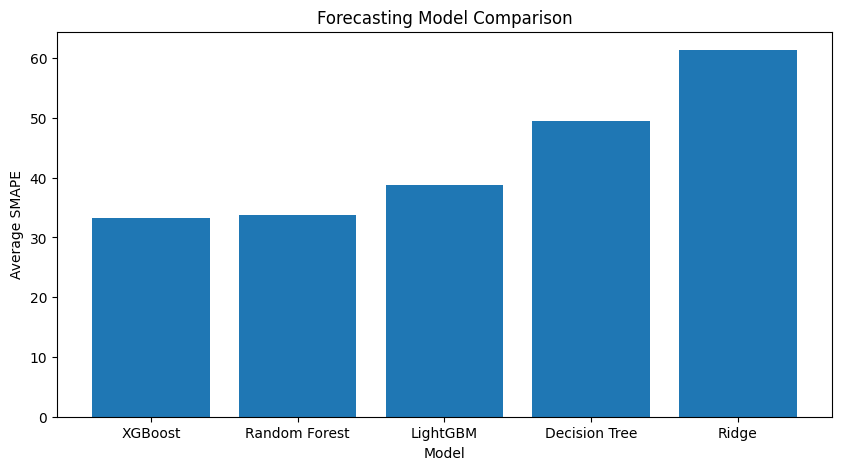

In [61]:
model_smape = pd.DataFrame({

    'Model': [

        'XGBoost',
        'Random Forest',
        'LightGBM',
        'Decision Tree',
        'Ridge'

    ],

    'SMAPE': [

        Final_M1['SMAPE'].mean(),
        Final_M2['SMAPE'].mean(),
        Final_M3['SMAPE'].mean(),
        Final_M4['SMAPE'].mean(),
        Final_M5['SMAPE'].mean()

    ]

})

plt.figure(figsize=(10,5))

plt.bar(
    model_smape['Model'],
    model_smape['SMAPE']
)

plt.xlabel("Model")

plt.ylabel("Average SMAPE")

plt.title("Forecasting Model Comparison")

plt.show()

## Final Model Selection

To identify highly reliable forecasts, predictions with:

SMAPE < 20%

were filtered separately for each forecasting model.

In [45]:

model_comparison = pd.DataFrame({

    'Model': [

        'XGBoost',
        'RandomForest',
        'LightGBM',
        'DecisionTree',
        'Ridge'

    ],

    'Regions_SMAPE_LT_20': [

        (
            Final_M1
            .groupby(
                'Material_Region'
            )['SMAPE']
            .max()
            .lt(20)
            .sum()
        ),

        (
            Final_M2
            .groupby(
                'Material_Region'
            )['SMAPE']
            .max()
            .lt(20)
            .sum()
        ),

        (
            Final_M3
            .groupby(
                'Material_Region'
            )['SMAPE']
            .max()
            .lt(20)
            .sum()
        ),

        (
            Final_M4
            .groupby(
                'Material_Region'
            )['SMAPE']
            .max()
            .lt(20)
            .sum()
        ),

        (
            Final_M5
            .groupby(
                'Material_Region'
            )['SMAPE']
            .max()
            .lt(20)
            .sum()
        )

    ]

})

model_comparison = (
    model_comparison
    .sort_values(
        by='Regions_SMAPE_LT_20',
        ascending=False
    )
)

model_comparison

,Model,Regions_SMAPE_LT_20
1,RandomForest,30
0,XGBoost,19
2,LightGBM,7
3,DecisionTree,7
4,Ridge,0


Based on the forecasting comparison results:

- XGBoost
- Random Forest
- LightGBM

demonstrated comparatively stronger forecasting performance and lower forecasting errors.

Decision Tree and Ridge Regression showed weaker forecasting performance and were therefore excluded from the final stacking ensemble model.

# Stacking Ensemble Forecasting Model

A stacking ensemble approach was implemented to improve forecasting accuracy by combining predictions from multiple high-performing machine learning models.

The ensemble used predictions generated from:

- XGBoost Regressor
- Random Forest Regressor
- LightGBM Regressor

These model predictions were used as meta-features for the final stacking model.

## Purpose of Stacking

The objective of stacking was to leverage the strengths of multiple forecasting models and reduce individual model weaknesses.

By combining multiple model outputs, the ensemble aims to:
- improve forecasting stability
- reduce forecasting error
- capture diverse demand patterns
- enhance generalization performance

In [46]:
# =========================
# CREATE STACKING DATAFRAME
# =========================

tuned_stack_df = pd.merge(

    df_out_of_time_results[
        [
            'Material_Region',
            'SalesMonth',
            'xgb_pred',
            'BilledQuantity_lead1_actual'
        ]
    ],

    rf_oot_results[
        [
            'Material_Region',
            'SalesMonth',
            'rf_pred'
        ]
    ],

    on=[
        'Material_Region',
        'SalesMonth'
    ],

    how='inner'

)

# =========================
# MERGE LIGHTGBM
# =========================

tuned_stack_df = pd.merge(

    tuned_stack_df,

    lgbm_oot_results[
        [
            'Material_Region',
            'SalesMonth',
            'lgbm_pred'
        ]
    ],

    on=[
        'Material_Region',
        'SalesMonth'
    ],

    how='inner'

)

# =========================
# RENAME TARGET COLUMN
# =========================

tuned_stack_df.rename(

    columns={
        'BilledQuantity_lead1_actual':
        'BilledQuantity_lead1'
    },

    inplace=True

)

print(tuned_stack_df.shape)

tuned_stack_df.head()    

(11238, 6)


,Material_Region,SalesMonth,xgb_pred,BilledQuantity_lead1,rf_pred,lgbm_pred
0,AHM_F2W5-48S-TZ4A,2025-10-01,9498.983398,9104,8895.978008,10134.672944
1,AHM_F2W5-48S-TZ4A,2025-11-01,8472.745117,5859,8614.974562,8151.826106
2,AHM_F2W5-48S-TZ4A,2025-12-01,6845.666504,7795,7892.644750,7083.440510
3,AHM_F2W5-48S-TZ4A,2026-01-01,8936.668945,10904,8670.800060,9772.843292
4,AHM_F2W5-48S-TZ4A,2026-02-01,11934.440430,10570,9773.282361,12080.464890


## Stacking Forecasting Strategy

A time-series aware stacking strategy was used.

The Out-of-Time (OOT) months were divided into:

| Usage | Months |
|---|---|
| Stack Training | Oct 2025 → Dec 2025 |
| Final Forecasting | Jan 2026 → Mar 2026 |

The first 3 OOT months were used to train the stacking meta-model, while the next 3 months were used for final forecasting evaluation.

In [47]:
# =========================
# SORT OOT MONTHS
# =========================

all_months = sorted(
    tuned_stack_df['SalesMonth'].unique()
)

print("All OOT Months:")
print(all_months)

# =========================
# STACK TRAIN MONTHS
# =========================

stack_train_months = all_months[:3]

# =========================
# FORECAST MONTHS
# =========================

stack_forecast_months = all_months[3:]

print("\nStack Train Months:")
print(stack_train_months)

print("\nForecast Months:")
print(stack_forecast_months)

All OOT Months:
[Timestamp('2025-10-01 00:00:00'), Timestamp('2025-11-01 00:00:00'), Timestamp('2025-12-01 00:00:00'), Timestamp('2026-01-01 00:00:00'), Timestamp('2026-02-01 00:00:00'), Timestamp('2026-03-01 00:00:00')]

Stack Train Months:
[Timestamp('2025-10-01 00:00:00'), Timestamp('2025-11-01 00:00:00'), Timestamp('2025-12-01 00:00:00')]

Forecast Months:
[Timestamp('2026-01-01 00:00:00'), Timestamp('2026-02-01 00:00:00'), Timestamp('2026-03-01 00:00:00')]


## Stack Train and Forecast Split

The stacking dataset was divided into:
- stack training data
- future forecasting data

This ensures realistic future forecasting validation without data leakage.

In [48]:
# =========================
# STACK TRAIN DATA
# =========================

stack_train = tuned_stack_df[
    tuned_stack_df['SalesMonth'].isin(
        stack_train_months
    )
]

# =========================
# STACK FORECAST DATA
# =========================

stack_forecast = tuned_stack_df[
    tuned_stack_df['SalesMonth'].isin(
        stack_forecast_months
    )
]

print(stack_train.shape)

print(stack_forecast.shape)

(5619, 6)
(5619, 6)


## Meta Features for Stacking

The following model predictions were used as meta-features for the stacking ensemble:

- XGBoost Predictions
- Random Forest Predictions
- LightGBM Predictions

In [49]:
# =========================
# STACK FEATURES
# =========================

stack_features = [

    'xgb_pred',
    'rf_pred',
    'lgbm_pred'

]

target = 'BilledQuantity_lead1'

## Stacking Meta Model

A Random Forest Regressor was used as the stacking meta-model to combine predictions from the base forecasting models.

In [50]:
from sklearn.ensemble import RandomForestRegressor

# =========================
# META MODEL
# =========================

meta_model = RandomForestRegressor(

    n_estimators=200,

    max_depth=10,

    random_state=42,

    n_jobs=-1

)

# =========================
# TRAIN META MODEL
# =========================

meta_model.fit(

    stack_train[stack_features],

    stack_train[target]

)

print("Stacking model trained successfully.")

Stacking model trained successfully.


## Final Forecast Generation

The trained stacking ensemble model was used to generate final demand forecasts for the future unseen months.

In [51]:
# =========================
# STACK FORECAST PREDICTIONS
# =========================

stack_forecast['stack_pred'] = meta_model.predict(

    stack_forecast[stack_features]

)

# =========================
# REMOVE NEGATIVES
# =========================

stack_forecast['stack_pred'] = np.maximum(

    0,

    stack_forecast['stack_pred']

)

## Stacking Model Evaluation

The forecasting performance of the stacking ensemble was evaluated using SMAPE to measure forecasting accuracy on future unseen months.

In [52]:
# =========================
# STACK SMAPE
# =========================

epsilon = 1

stack_forecast['SMAPE'] = (

    np.abs(

        stack_forecast['BilledQuantity_lead1']

        -

        stack_forecast['stack_pred']

    )

    /

    (

        (

            np.abs(
                stack_forecast['BilledQuantity_lead1']
            )

            +

            np.abs(
                stack_forecast['stack_pred']
            )

        ) / 2

        + epsilon

    )

) * 100

## Final Stacking Forecast Results

The final dataframe below contains:

- Actual demand values
- Final ensemble forecasts
- Forecasting SMAPE values
- Future Out-of-Time forecast results

This represents the final ensemble forecasting output generated using the stacking approach.

In [53]:
stack_forecast[
    [

        'Material_Region',
        'SalesMonth',
        'BilledQuantity_lead1',
        'stack_pred',
        'SMAPE'

    ]
]

,Material_Region,SalesMonth,BilledQuantity_lead1,stack_pred,SMAPE
3,AHM_F2W5-48S-TZ4A,2026-01-01,10904,8374.097724,26.243667
4,AHM_F2W5-48S-TZ4A,2026-02-01,10570,10803.706443,2.186655
5,AHM_F2W5-48S-TZ4A,2026-03-01,7204,6436.430214,11.252684
9,AHM_F2W5-48S-TZ5A,2026-01-01,2697,2400.423491,11.631766
10,AHM_F2W5-48S-TZ5A,2026-02-01,1717,2219.420360,25.513801
...,...,...,...,...,...
11230,VIJ_HX00-STAR24V2550,2026-02-01,61,56.865552,6.898476
11231,VIJ_HX00-STAR24V2550,2026-03-01,78,53.252345,37.144044
11235,VIJ_KX00-024EXIDEN020,2026-01-01,24,33.602609,32.222110
11236,VIJ_KX00-024EXIDEN020,2026-02-01,23,23.883247,3.613699


# Final Stacking Ensemble Forecast

The following visualization compares actual demand values against final ensemble forecasts generated using the stacking model.

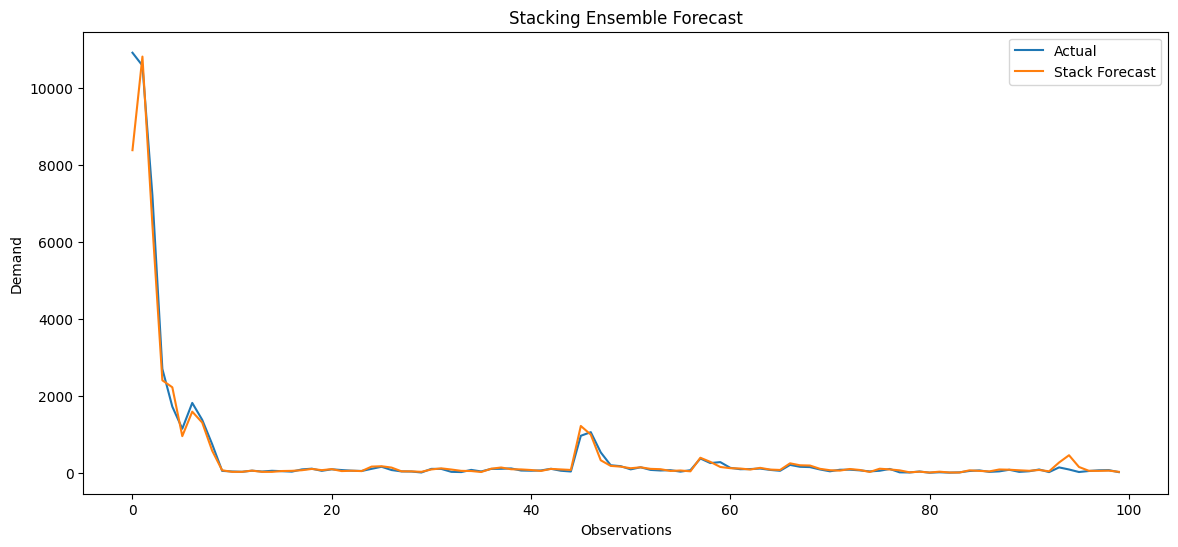

In [62]:
stack_sample = stack_forecast.head(100)

plt.figure(figsize=(14,6))

plt.plot(

    stack_sample['BilledQuantity_lead1'].values,

    label='Actual'

)

plt.plot(

    stack_sample['stack_pred'].values,

    label='Stack Forecast'

)

plt.xlabel("Observations")

plt.ylabel("Demand")

plt.title("Stacking Ensemble Forecast")

plt.legend()

plt.show()

# Conclusion

This project implemented a machine learning based demand forecasting pipeline using multiple ensemble and regression models.

The workflow included:
- Out-of-Time forecasting
- lag and rolling statistical feature utilization
- hyperparameter tuning
- forecasting error analysis
- model comparison
- stacking ensemble forecasting

The forecasting models were evaluated using:
- SMAPE
- RMSE
- WAPE

Among the trained models:
- XGBoost
- Random Forest
- LightGBM

demonstrated comparatively stronger forecasting performance and were selected for the final stacking ensemble.

Decision Tree and Ridge Regression showed comparatively weaker forecasting performance and were excluded from the final ensemble pipeline.

A stacking ensemble using Random Forest as the meta-model was implemented to combine predictions from the best-performing models and improve forecasting stability.

The project also included:
- high-accuracy forecast filtering
- low SMAPE analysis
- Out-of-Time validation
- high-volume runner product forecasting

Overall, the final forecasting pipeline demonstrated effective demand prediction capability for high-demand product categories across multiple regions.